In [1]:
# The purpose of this code is to make enrichment analysis of non preserved modules
# The preservation analysis was already done in previous notebook

library(clusterProfiler)
library(ggplot2)
library(org.Hs.eg.db)
library(WGCNA)



clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang,
W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize
multiomics data. Nature Protocols. 2024, 19(11):3292-3320


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames

In [2]:
setwd("/home/seba/github_repos/crc_weighted_network")

In [3]:
# First: intra module preservation normal vs tumor - TAIWAN
taiwan_normal_net <- readRDS("taiwanese_cohort/rna_normal/blockwise_net.rds")
mp <- readRDS("taiwanese_cohort/TAIWAN_intra_module_preservation_normal_vs_tumor.rds")

stats_preservacion <- mp$preservation$Z[[1]][[2]]

# 2. Filtrar los nombres de las filas donde Zsummary es menor a 5
# Excluimos 'gold' y 'grey' porque ya sabemos que no nos interesan para enriquecimiento
modules_of_interest <- rownames(stats_preservacion)[
  stats_preservacion[, "Zsummary.pres"] < 5 & 
  !(rownames(stats_preservacion) %in% c("gold", "grey"))
]

gene2color <- as.data.frame(taiwan_normal_net$colors)
colnames(gene2color) <- c("color")
gene2color$color <- labels2colors(gene2color$color)

genes_to_test <- rownames(gene2color)[gene2color$color %in% modules_of_interest]

In [4]:
length(modules_of_interest)
# no hay genes entrez

[1] 0

In [5]:
# Second: intra module preservation tumor vs normal - TAIWAN
taiwan_tumor_net <- readRDS("taiwanese_cohort/rna_tumor/blockwise_net.rds")

mp <- readRDS("taiwanese_cohort/TAIWAN_intra_module_preservation_tumor_vs_normal.rds")

stats_preservacion <- mp$preservation$Z[[1]][[2]]

# 2. Filtrar los nombres de las filas donde Zsummary es menor a 2
# Excluimos 'gold' y 'grey' porque ya sabemos que no nos interesan para enriquecimiento
modules_of_interest <- rownames(stats_preservacion)[
  stats_preservacion[, "Zsummary.pres"] < 5 & 
  !(rownames(stats_preservacion) %in% c("gold", "grey"))
]

gene2color <- as.data.frame(taiwan_tumor_net$colors)
colnames(gene2color) <- c("color")
gene2color$color <- labels2colors(gene2color$color)

genes_to_test <- rownames(gene2color)[gene2color$color %in% modules_of_interest]
genes_to_test <- gsub("\\..*", "", genes_to_test) # remove version number from gene names
genes_entrez <- bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", :
“0.61% of input gene IDs are fail to map...”


In [6]:
length(modules_of_interest)
length(genes_entrez$ENTREZID)

[1] 10

[1] 1974

In [7]:
kegg_results <- enrichKEGG(gene = genes_entrez$ENTREZID, organism = "hsa", pvalueCutoff = 0.05)

Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...



In [8]:
svg("sup_11a.svg")
dotplot(kegg_results, showCategory=5) + ggtitle("KEGG Pathway Enrichment")
dev.off()

pdf 
  2

In [9]:
# Hacer lo mismo pero para la cohorte blanca
white_normal_net <- readRDS("cohort_white/rna_normal_tmm0.4/blockwise_net.rds")

mp <- readRDS("cohort_white/WHITE_intra_module_preservation_normal_vs_tumor.rds")
stats_preservacion <- mp$preservation$Z[[1]][[2]]

# 2. Filtrar los nombres de las filas donde Zsummary es menor a 2
# Excluimos 'gold' y 'grey' porque ya sabemos que no nos interesan para enriquecimiento
modules_of_interest <- rownames(stats_preservacion)[
  stats_preservacion[, "Zsummary.pres"] < 5 & 
  !(rownames(stats_preservacion) %in% c("gold", "grey"))
]

gene2color <- as.data.frame(white_normal_net$colors)
colnames(gene2color) <- c("color")
gene2color$color <- labels2colors(gene2color$color)

genes_to_test <- rownames(gene2color)[gene2color$color %in% modules_of_interest]
genes_to_test <- gsub("\\..*", "", genes_to_test) # remove version number from gene names
genes_entrez <- bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", :
“0.63% of input gene IDs are fail to map...”


In [10]:
length(modules_of_interest)
length(genes_entrez$ENTREZID)

[1] 1

[1] 315

In [11]:
kegg_results <- enrichKEGG(gene = genes_entrez$ENTREZID, organism = "hsa", pvalueCutoff = 0.05)

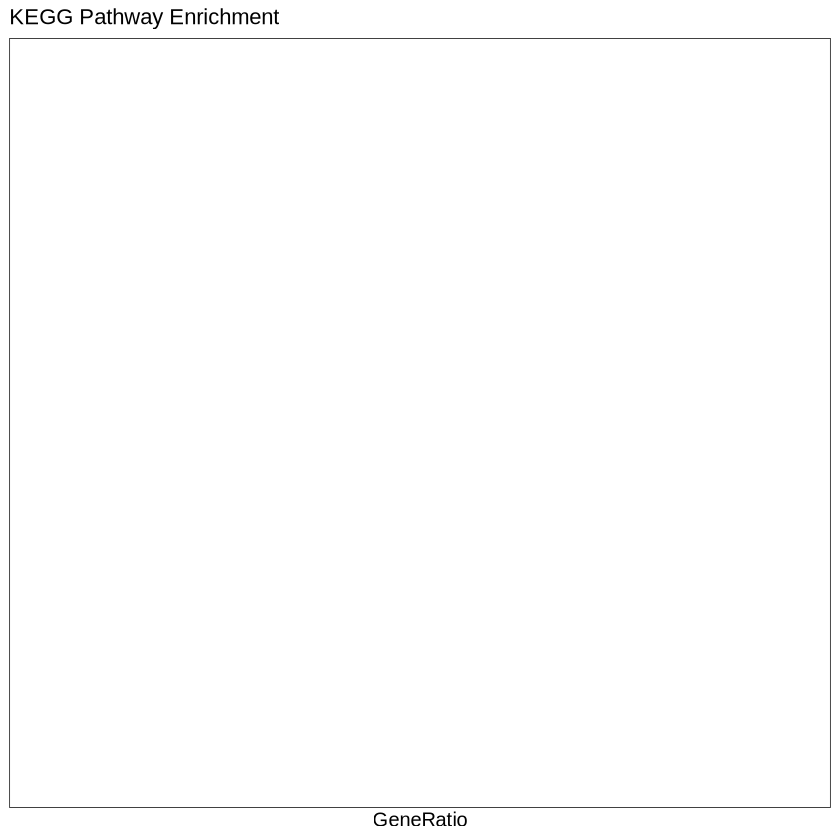

In [12]:
dotplot(kegg_results, showCategory=5) + ggtitle("KEGG Pathway Enrichment")

In [13]:
# blanco pero tumoral vs normal
white_tumor_net <- readRDS("cohort_white/rna_tumor_tmm0.4/blockwise_net.rds")

mp <- readRDS("cohort_white/WHITE_intra_module_preservation_tumor_vs_normal.rds")
stats_preservacion <- mp$preservation$Z[[1]][[2]]

# 2. Filtrar los nombres de las filas donde Zsummary es menor a 2
# Excluimos 'gold' y 'grey' porque ya sabemos que no nos interesan para enriquecimiento
modules_of_interest <- rownames(stats_preservacion)[
  stats_preservacion[, "Zsummary.pres"] < 5 & 
  !(rownames(stats_preservacion) %in% c("gold", "grey"))
]

gene2color <- as.data.frame(white_normal_net$colors)
colnames(gene2color) <- c("color")
gene2color$color <- labels2colors(gene2color$color)

genes_to_test <- rownames(gene2color)[gene2color$color %in% modules_of_interest]
genes_to_test <- gsub("\\..*", "", genes_to_test) # remove version number from gene names
genes_entrez <- bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", :
“1.28% of input gene IDs are fail to map...”


In [14]:
length(modules_of_interest)
length(genes_entrez$ENTREZID)

[1] 9

[1] 934

In [15]:
kegg_results <- enrichKEGG(gene = genes_entrez$ENTREZID, organism = "hsa", pvalueCutoff = 0.05)

In [16]:
svg("sup_11b.svg")
dotplot(kegg_results, showCategory=5) + ggtitle("KEGG Pathway Enrichment")
dev.off()

pdf 
  2

In [17]:
# TO DO
# TUMORAL VS TUMORAL WHITE VS TAIWAN
# TUMORAL VS TUMORAL TAIWAN VS WHITE

# NORMAL VS NORMAL TAIWAN VS WHITE

In [18]:
mp <- readRDS("TAIWANVSWHITE_inter_normal_module_preservation.rds")
stats_preservacion <- mp$preservation$Z[[1]][[2]]

modules_of_interest <- rownames(stats_preservacion)[
  stats_preservacion[, "Zsummary.pres"] < 5 & 
  !(rownames(stats_preservacion) %in% c("gold", "grey"))
]

gene2color <- as.data.frame(taiwan_normal_net$colors)
colnames(gene2color) <- c("color")
gene2color$color <- labels2colors(gene2color$color)

genes_to_test <- rownames(gene2color)[gene2color$color %in% modules_of_interest]
genes_to_test <- gsub("\\..*", "", genes_to_test) # remove version number from gene names
genes_entrez <- bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", :
“1.66% of input gene IDs are fail to map...”


In [19]:
length(modules_of_interest)
length(genes_entrez$ENTREZID)

[1] 21

[1] 2683

In [20]:
kegg_results <- enrichKEGG(gene = genes_entrez$ENTREZID, organism = "hsa", pvalueCutoff = 0.05)

In [21]:
svg("sup_12a.svg")
dotplot(kegg_results, showCategory=5) + ggtitle("KEGG Pathway Enrichment")
dev.off()

pdf 
  2

In [22]:
mp <- readRDS("TAIWANVSWHITE_inter_tumor_module_preservation.rds")
stats_preservacion <- mp$preservation$Z[[1]][[2]]

modules_of_interest <- rownames(stats_preservacion)[
  stats_preservacion[, "Zsummary.pres"] < 5 & 
  !(rownames(stats_preservacion) %in% c("gold", "grey"))
]

gene2color <- as.data.frame(taiwan_tumor_net$colors)
colnames(gene2color) <- c("color")
gene2color$color <- labels2colors(gene2color$color)

genes_to_test <- rownames(gene2color)[gene2color$color %in% modules_of_interest]
genes_to_test <- gsub("\\..*", "", genes_to_test) # remove version number from gene names
genes_entrez <- bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

'select()' returned 1:many mapping between keys and columns



In [23]:
length(modules_of_interest)
length(genes_entrez$ENTREZID)

[1] 1

[1] 115

In [24]:
kegg_results <- enrichKEGG(gene = genes_entrez$ENTREZID, organism = "hsa", pvalueCutoff = 0.05)

In [25]:
svg("sup_12b.svg")
dotplot(kegg_results, showCategory=5) + ggtitle("KEGG Pathway Enrichment")
dev.off()

pdf 
  2

In [26]:
mp <- readRDS("WHITEVSTAIWAN_inter_normal_module_preservation.rds")
stats_preservacion <- mp$preservation$Z[[1]][[2]]

modules_of_interest <- rownames(stats_preservacion)[
  stats_preservacion[, "Zsummary.pres"] < 5 & 
  !(rownames(stats_preservacion) %in% c("gold", "grey"))
]

gene2color <- as.data.frame(white_normal_net$colors)
colnames(gene2color) <- c("color")
gene2color$color <- labels2colors(gene2color$color)

genes_to_test <- rownames(gene2color)[gene2color$color %in% modules_of_interest]
genes_to_test <- gsub("\\..*", "", genes_to_test) # remove version number from gene names
genes_entrez <- bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", :
“4.81% of input gene IDs are fail to map...”


In [27]:
length(modules_of_interest)
length(genes_entrez$ENTREZID)

[1] 9

[1] 365

In [28]:
kegg_results <- enrichKEGG(gene = genes_entrez$ENTREZID, organism = "hsa", pvalueCutoff = 0.05)

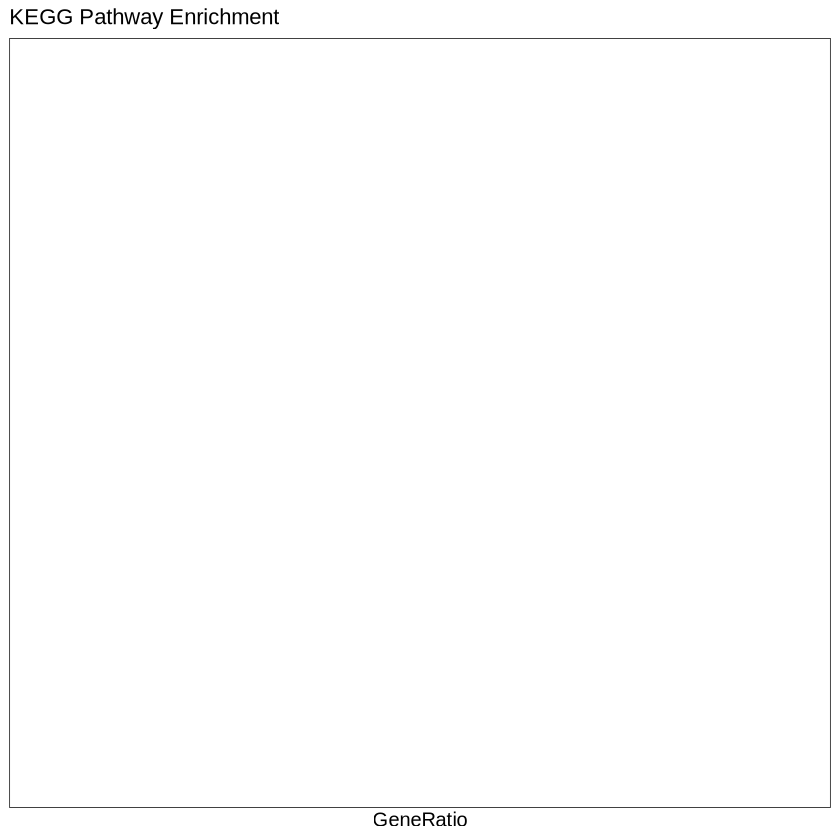

In [29]:
dotplot(kegg_results, showCategory=5) + ggtitle("KEGG Pathway Enrichment")

In [30]:
mp <- readRDS("WHITEVSTAIWAN_inter_tumor_module_preservation.rds")
stats_preservacion <- mp$preservation$Z[[1]][[2]]

modules_of_interest <- rownames(stats_preservacion)[
  stats_preservacion[, "Zsummary.pres"] < 5 & 
  !(rownames(stats_preservacion) %in% c("gold", "grey"))
]

gene2color <- as.data.frame(white_tumor_net$colors)
colnames(gene2color) <- c("color")
gene2color$color <- labels2colors(gene2color$color)

genes_to_test <- rownames(gene2color)[gene2color$color %in% modules_of_interest]
genes_to_test <- gsub("\\..*", "", genes_to_test) # remove version number from gene names
genes_entrez <- bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

In [31]:
length(modules_of_interest)
length(genes_entrez$ENTREZID)

[1] 0

[1] 0

In [32]:
kegg_results <- enrichKEGG(gene = genes_entrez$ENTREZID, organism = "hsa", pvalueCutoff = 0.05)

--> No gene can be mapped....

--> Expected input gene ID: 7923,2582,3417,414328,5236,10327

--> return NULL...



In [33]:
#dotplot(kegg_results, showCategory=20) + ggtitle("KEGG Pathway Enrichment")
# NO DA NADA

In [34]:
taiwan_global_net <- readRDS("taiwanese_cohort/rna_pooled_tmm/blockwise_net.rds")
mp <- readRDS("TAIWANVSWHITE_inter_module_preservation_GLOBAL.rds")

stats_preservacion <- mp$preservation$Z[[1]][[2]]

modules_of_interest <- rownames(stats_preservacion)[
  stats_preservacion[, "Zsummary.pres"] < 5 & 
  !(rownames(stats_preservacion) %in% c("gold", "grey"))
]

gene2color <- as.data.frame(white_tumor_net$colors)
colnames(gene2color) <- c("color")
gene2color$color <- labels2colors(gene2color$color)

genes_to_test <- rownames(gene2color)[gene2color$color %in% modules_of_interest]
genes_to_test <- gsub("\\..*", "", genes_to_test) # remove version number from gene names
genes_entrez <- bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

'select()' returned 1:many mapping between keys and columns



In [35]:
length(modules_of_interest)
length(genes_entrez$ENTREZID)

[1] 2

[1] 584

In [36]:
kegg_results <- enrichKEGG(gene = genes_entrez$ENTREZID, organism = "hsa", pvalueCutoff = 0.05)

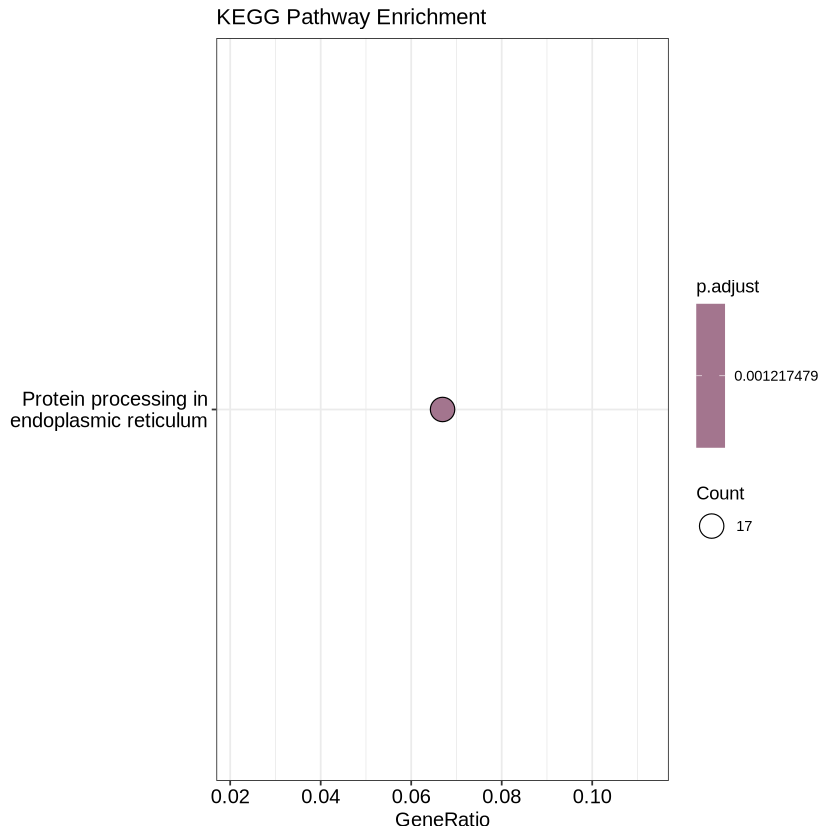

In [37]:
dotplot(kegg_results, showCategory=5) + ggtitle("KEGG Pathway Enrichment")

In [38]:
white_global_net <- readRDS("cohort_white/rna_pooled_tmm0.4/blockwise_net.rds")
mp <- readRDS("WHITEVSTAIWAN_inter_module_preservation_GLOBAL.rds")

stats_preservacion <- mp$preservation$Z[[1]][[2]]

modules_of_interest <- rownames(stats_preservacion)[
  stats_preservacion[, "Zsummary.pres"] < 5 & 
  !(rownames(stats_preservacion) %in% c("gold", "grey"))
]

gene2color <- as.data.frame(white_tumor_net$colors)
colnames(gene2color) <- c("color")
gene2color$color <- labels2colors(gene2color$color)

genes_to_test <- rownames(gene2color)[gene2color$color %in% modules_of_interest]
genes_to_test <- gsub("\\..*", "", genes_to_test) # remove version number from gene names
genes_entrez <- bitr(genes_to_test, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

'select()' returned 1:many mapping between keys and columns



In [39]:
length(modules_of_interest)
length(genes_entrez$ENTREZID)

[1] 1

[1] 379

In [40]:
kegg_results <- enrichKEGG(gene = genes_entrez$ENTREZID, organism = "hsa", pvalueCutoff = 0.05)

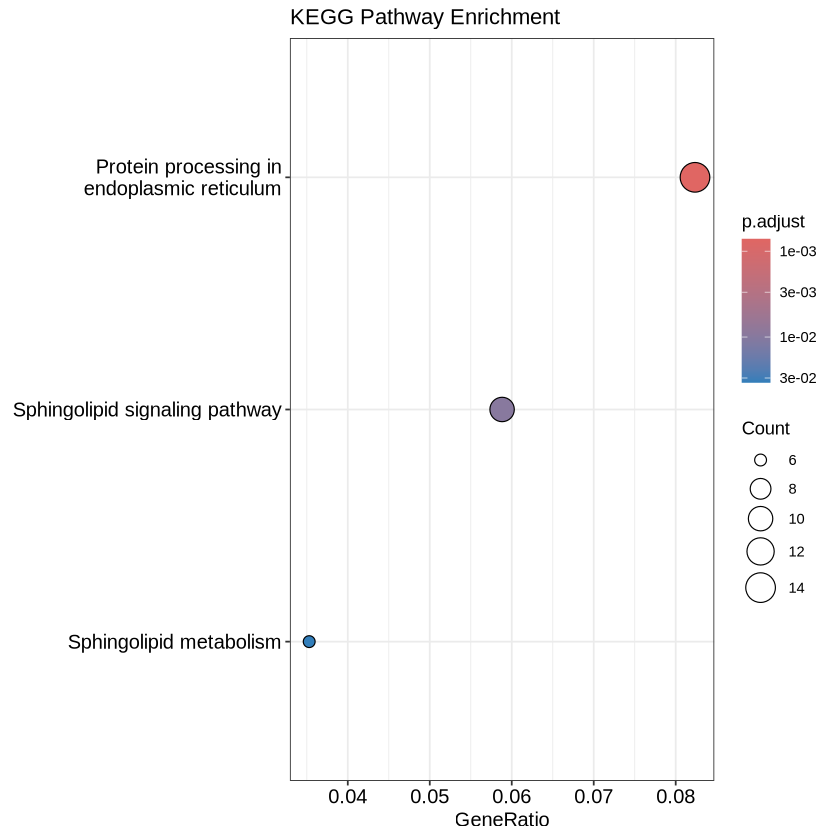

In [41]:
dotplot(kegg_results, showCategory=5) + ggtitle("KEGG Pathway Enrichment")